# Trabajo Práctico de Laboratorio 2 <img src="fig/logo_utn_encabezado.png" width="250" align="right"/>
## Teoría de los Circuitos II
### Docentes: Mariano Llamedo Soria, David Moharos, César Fuoco
### por Julián Galeano Pinazo


En este trabajo práctico, se diseñaron e implementaron dos filtros digitales en una placa de desarollo ST Nucleo64-F446. Se midió la respuesta de módulo en frecuencia con un osciloscopio y con un analizador de audio, con el objetivo de comparar ambos resultados.

#### Objetivos

1. Diseñar e implementar filtros digitales.
2. Comprobar la facilidad de implementación de estos y como emulan el comportamiento de un filtro analógico.

#### Diseño

Los filtros se probaron sobre un microcontrolador STM32F446 en su placa de desarrollo Nucleo64. Se utilizó la librería de DSP de ARM _cmsis_dsp_ para implementar los filtros con las funciones _arm_fir_f32_ y _arm_biquad_cascade_df1_f32_, a las cuales hay que pasarle los coeficientes del filtro. Se configuró el ADC del microcontrolador con una $f_s = 1000Hz$, por lo que la frecuencia de Nyquist con la que se trabajó es $f_N=500Hz$.

Estos coeficientes se calcularon mediante las funciones de diseño del módulo de Python _scipy.signal_.

Se implementaron los siguientes filtros:

* Pasa-bajos FIR
    * Funcion de aproximación: Chevyshev
    * Frecuencia de corte $f_c =$ 100Hz
    * Atenuación máxima en banda de paso $\alpha_{max} =$ 1dB
    * Frecuencia de rechazo $f_s =$ 300Hz
    * Atenuación mínima en banda de rechazo $\alpha_{min} =$ 60dB
* Filtro Notch IIR
    * Frecuencia de notch $f_n =$ 50Hz
    * Ancho de banda $BW =$ 1Hz
    * Atenuación máxima en banda de paso $\alpha_{max} =$ 3dB

El filtro IIR se implementó en SOS. A continuación el script de Python que se utilizó para calcular los coeficientes de ambos filtros:

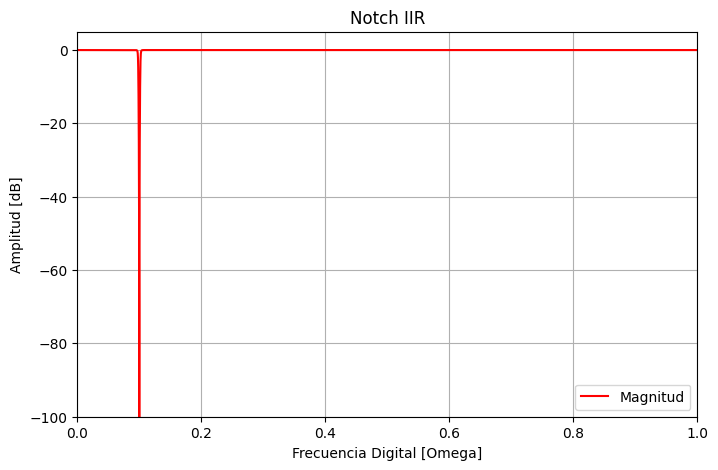

notch iir:
[[0.9876471423021117, -1.8786196529406052, 0.9876471423021115, 1.0, -1.8903677129750165, 0.9876469052131024, ],
[1.0, -1.9021162239802782, 0.9999999999999998, 1.0, -1.8927552321046763, 0.9937022008774528, ],
[1.0, -1.9021162239802782, 0.9999999999999998, 1.0, -1.8995831289805998, 0.9939068047942485, ],
]


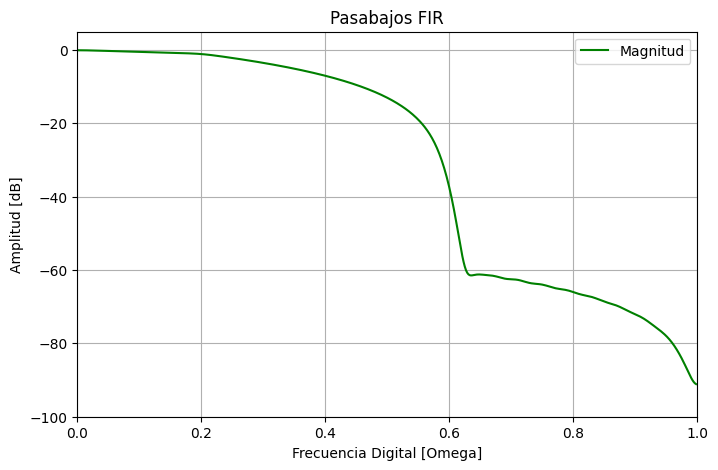

Orden del filtro FIR = 101


In [6]:
import numpy as np
import scipy.signal as sp
from matplotlib import pyplot as plt

## FILTRO NOTCH IIR

b1,a1 = sp.iirdesign([0.098, 0.102], [0.0999, 0.1001], 3, 60, ftype='butter')
sos1 = sp.iirdesign([0.098, 0.102], [0.0999, 0.1001], 3, 60, output='sos', ftype='butter')
w1, h1 = sp.freqz(b1,a1, worN=8000)

wiir = w1/(np.pi)
magiir = 20 * np.log10(np.abs(h1))

plt.figure(figsize=(8, 5))
plt.plot(wiir, magiir, 'r', label='Magnitud')
plt.title("Notch IIR")
plt.xlabel('Frecuencia Digital [Omega]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.legend()
plt.xlim(0,1)
plt.ylim(-100, 5)  # Ajustar límite del eje Y para ver la caída
plt.show()

print("notch iir:")
print("[", end="")

for i in sos1:
    print("[", end="")
    for j in i:
        print(f"{j}, ", end="")
    print("],")
print("]")


## FILTRO PASABAJOS FIR

fc = 0.2
amax = 1
fs = 0.6
amin = 60
N = 101

frecs = [0, fc, fs, 1]
gains = [0, -amax, -amin, -np.inf]
gains = 10**(np.array(gains)/20)

bfir = sp.firwin2(N, frecs, gains , window='hamming')
wfir, hfir = sp.freqz(bfir, 1.0)
wfir = wfir/(np.pi)
magfir = 20 * np.log10(np.abs(hfir))

plt.figure(figsize=(8, 5))
plt.plot(wfir, magfir, 'g', label='Magnitud')
plt.title("Pasabajos FIR")
plt.xlabel('Frecuencia Digital [Omega]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.legend()
plt.xlim(0,1)
plt.ylim(-100, 5)  # Ajustar límite del eje Y para ver la caída
plt.show()

print(f"Orden del filtro FIR = {len(bfir)}")

#Se comenta este bloque para que los 101 coeficientes del filtro no ocupen lugar
#print("lowpass fir:")
#print("[", end="")
#for i in bfir:
#    print(f"{i},", end="")
#print("]")


Se eligió una topología Multiple Feedback para implementarlo:

<figure>
    <img src="fig/esquema.png"  width="700"/>
    <figcaption align="center"><b>Figura 1:</b> Esquema de prueba del filtro.</figcaption>
</figure>

Los filtros antialias y de interpolación se diseñaron para ser iguales, pasabajos RC de orden 1 con frecuencia de corte $f_c=300Hz$. Se armaron ambos filtros en una placa preperforada junto con una tira de pines hembra para conectarlo a la placa de desarrollo en forma de "shield".

<figure>
    <img src="fig/shield.png"  width="700"/>
    <figcaption align="center"><b>Figura 2:</b> Placa con los filtros antialias e interpolador.</figcaption>
</figure>


#### Armado

#### Resultados

##### Mediciones

Las mediciones se realizaron, primero, con un osciloscopio y un generador de señales siguiendo la siguiente metodología:

* El generador de señales genera una señal sinusoide.
* El osciloscopio se conecta con un canal en la entrada y otro en la salida del filtro.
* Se varía la frecuencia de la señal para realizar distintas mediciones.

A cada frecuencia:
1. Se miden Vi y Vo, de pico a pico.
2. El módulo de la respuesta en frecuencia es $A=\frac{Vo}{Vi}$, expresada en dB

Se realizaron 18 mediciones distribuídas entre 100 y 100000 Hz, con 9 de estas concentradas en la banda de paso.

In [16]:
import pandas as pd

#MEDICIONES REALIZADAS CON EL OSCILOSCOPIO - LPF FIR

lpf_fir = pd.read_csv('mediciones/lp_fir.csv')

print("Mediciones realizadas con el osciloscopio - LPF FIR:")
lpf_fir.style.hide(axis='index')

Mediciones realizadas con el osciloscopio - LPF FIR:


f [Hz],Vin [V],Vout [V],A [dB]
30,2.110000,1.960000,-0.640528
50,2.200000,1.870000,-1.411621
70,2.150000,1.750000,-1.788008
80,2.160000,1.670000,-2.234746
90,2.160000,1.630000,-2.445323
100,2.110000,1.600000,-2.403249
110,2.100000,1.510000,-2.864847
130,2.070000,1.270000,-4.243332
150,2.070000,1.080000,-5.650932
200,2.050000,0.576000,-11.026628


In [17]:
import pandas as pd

#MEDICIONES REALIZADAS CON EL OSCILOSCOPIO - NOTCH IIR

notch_iir = pd.read_csv('mediciones/notch_iir.csv')

print("Mediciones realizadas con el osciloscopio - Notch IIR:")
notch_iir.style.hide(axis='index')

Mediciones realizadas con el osciloscopio - Notch IIR:


f [Hz],Vin [V],Vout [V],A [dB]
40.000000,3.350000,3.030000,-0.872044
45.000000,3.270000,2.960000,-0.865121
49.000000,3.270000,2.240000,-3.285995
49.200000,3.160000,1.550000,-6.187108
49.500000,3.350000,0.520000,-16.180829
49.700000,3.240000,0.200000,-24.190300
49.900000,3.240000,0.121000,-28.555193
50.000000,3.160000,0.080000,-31.931942
50.200000,3.110000,0.085000,-31.266829
50.500000,3.110000,0.360000,-18.729158


A continuación, un grafico de las mediciones:

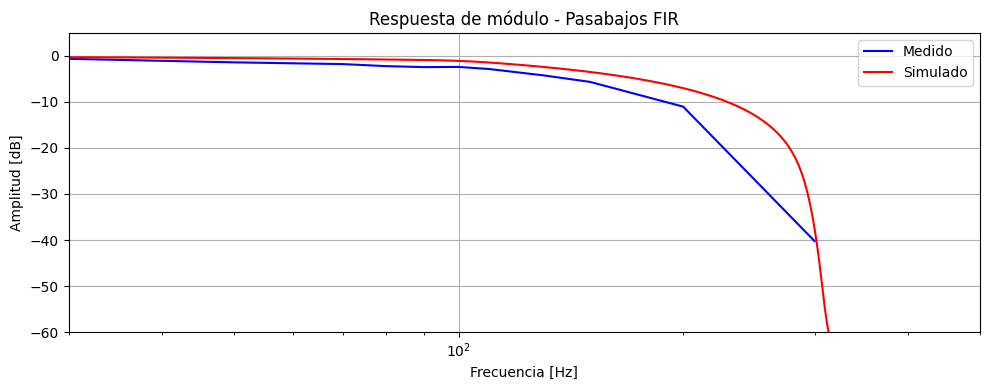

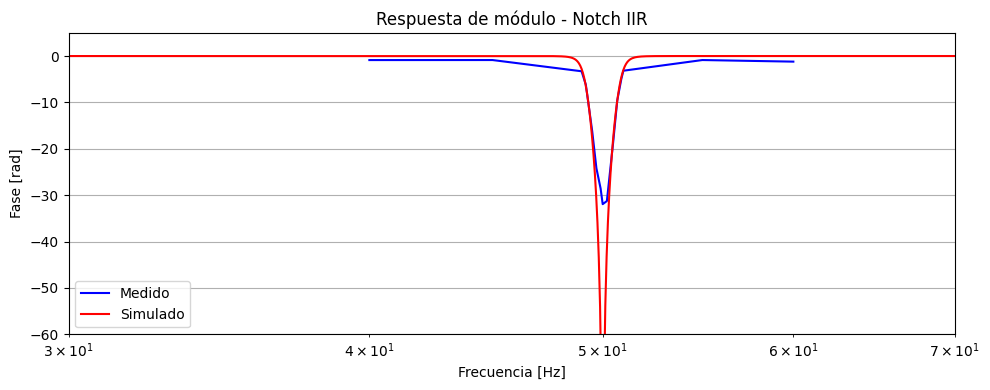

In [29]:
from matplotlib import pyplot as plt

wfir_scaled = wfir*500
wiir_scaled = wiir*500

plt.figure(figsize=(10, 4))
plt.title("Respuesta de módulo - Pasabajos FIR")
plt.semilogx(lpf_fir.iloc[:, 0], lpf_fir.iloc[:, 3], 'b', label='Medido')
plt.semilogx(wfir_scaled, magfir, 'r', label='Simulado')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.xlim(30,500)
plt.ylim(-60,5)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.title("Respuesta de módulo - Notch IIR")
plt.semilogx(notch_iir.iloc[:, 0], notch_iir.iloc[:, 3], 'b', label='Medido')
plt.semilogx(wiir_scaled, magiir, 'r', label='Simulado')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True)
plt.xlim(30,70)
plt.ylim(-60,5)
plt.xscale('log')
plt.legend()

plt.tight_layout()
plt.show()

Luego, se realizaron mediciones con un analizador de audio sobre el filtro pasa bajos FIR:

<figure>
    <img src="mediciones/analizador.png"  width="800"/>
    <figcaption align="center"><b>Figura 3:</b> Respuesta del filtro LPF FIR medida con el analizador de audio.</figcaption>
</figure>

#### Conclusiones

Debido a que en el setup de medición que se utilizó se hizo pasar a la señal por dos filtros pasa-bajo con 3dB de atenuación en 300Hz, lo esperable es que la respuesta de módulo a esa frecuencia este a -6dB en las mediciones respecto a los valores simulados. Observando ambas mediciones del filtro Pasa-bajos, no se puede observar esto: en las mediciones con osciloscopio se tiene -40dB en 300Hz igual que en la simulación, y en las del analizador de audio se tiene -62dB en el codo de la frecuencia de rechazo, igual que en la simulación. LLama la atención que este codo en las mediciones del analizador de audio esta en 358Hz, a diferencia de la simulación que lo tiene en aproximadamente 325Hz. Puede ser un problema de escala, pero es dificil de saber.

Las mediciones del filtro Notch con osciloscopio se aproximan mucho a los valores de la simulación, llegando a 32dB de atenuación en la frecuencia central.